In [1]:
#
# 1. cleaning data
#
# import the necessaries libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from datetime import datetime
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings("ignore")

fraud_df = pd.read_csv("../data/raw/fraud_data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_data.csv")

In [2]:
# handle missing values
fraud_df.isnull().sum()

num_cols = fraud_df.select_dtypes(include=np.number).columns
cat_cols = fraud_df.select_dtypes(include="object").columns

fraud_df[num_cols] = fraud_df[num_cols].fillna(fraud_df[num_cols].median())
fraud_df[cat_cols] = fraud_df[cat_cols].fillna(fraud_df[cat_cols].mode().iloc[0])

In [3]:
# remove duplicate values
fraud_df = fraud_df.drop_duplicates()

In [4]:
# correct data types
fraud_df["signup_time"] = pd.to_datetime(fraud_df["signup_time"])
fraud_df["purchase_time"] = pd.to_datetime(fraud_df["purchase_time"])
fraud_df["ip_address"] = fraud_df["ip_address"].astype(int)

Text(0.5, 1.0, 'Distribution of Purchase Value')

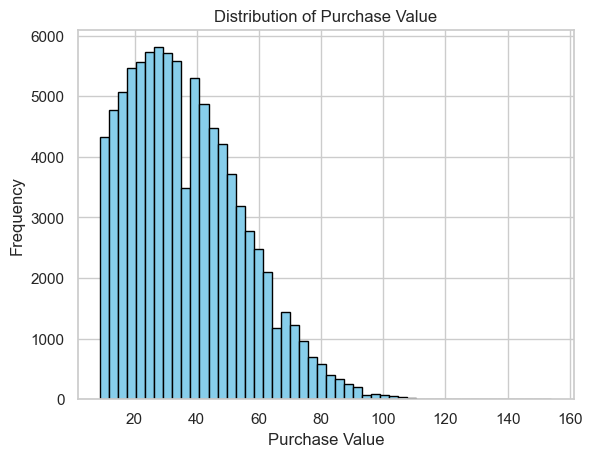

In [5]:
#
# 2. EDA 
#

# univariable analysis
fraud_df.describe()

# Histogram with axis labels
ax = fraud_df["purchase_value"].hist(bins=50, color="skyblue", edgecolor="black")

ax.set_xlabel("Purchase Value")      
ax.set_ylabel("Frequency")           
ax.set_title("Distribution of Purchase Value")  


In [6]:
# bivariante analysis
fraud_df.groupby("class")["purchase_value"].mean()
fraud_df.groupby("class")["age"].mean()

class
0.0    33.097983
1.0    33.248981
Name: age, dtype: float64

In [7]:
# class distribution analysis *+(imbalance)
fraud_df["class"].value_counts(normalize=True)

class
0.0    0.906892
1.0    0.093108
Name: proportion, dtype: float64

In [8]:
# 3. Geolocation Integration
# convert ipaddress to integer
fraud_df["ip_address"] = fraud_df["ip_address"].astype(int)

In [9]:
# Range-Based IP to Country Merge
ip_df["lower_bound_ip_address"] = ip_df["lower_bound_ip_address"].astype(int)
ip_df["upper_bound_ip_address"] = ip_df["upper_bound_ip_address"].astype(int)

fraud_df = fraud_df.sort_values("ip_address")
ip_df = ip_df.sort_values("lower_bound_ip_address")

fraud_df["country"] = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)["country"]

In [10]:
# Fraud Analysis by Country
fraud_df.groupby("country")["class"].mean().sort_values(ascending=False)


country
Djibouti                          0.500000
Guam                              0.333333
Mongolia                          0.333333
Mozambique                        0.285714
Palestinian Territory Occupied    0.285714
                                    ...   
South Sudan                       0.000000
Turkmenistan                      0.000000
Uganda                            0.000000
Uzbekistan                        0.000000
Virgin Islands (U.S.)             0.000000
Name: class, Length: 168, dtype: float64

In [11]:
# 4. Feature Engineering
# time based feature
fraud_df["hour_of_day"] = fraud_df["purchase_time"].dt.hour
fraud_df["day_of_week"] = fraud_df["purchase_time"].dt.dayofweek

fraud_df["time_since_signup"] = (
    fraud_df["purchase_time"] - fraud_df["signup_time"]
).dt.total_seconds() / 3600

In [12]:
# Transaction Frequency & Velocity
fraud_df = fraud_df.sort_values(["user_id", "purchase_time"])

fraud_df["txn_count_24h"] = (
    fraud_df
    .groupby("user_id")["purchase_time"]
    .transform(lambda x: x.diff().dt.total_seconds().lt(86400).cumsum())
)


In [14]:
# 5. Data Transformation
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scale_cols = ["purchase_value", "time_since_signup", "txn_count_24h"]
scaler = StandardScaler()
fraud_df[scale_cols] = scaler.fit_transform(fraud_df[scale_cols])


In [16]:
print(fraud_df.columns.tolist())

['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'age', 'ip_address', 'class', 'hour_of_day', 'day_of_week', 'time_since_signup', 'txn_count_24h', 'sex_M', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'source_Direct', 'source_SEO', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Cambodia', 'country_Cameroon', 'country_Canada', 'country_Cayman Islands', 'country_Chile', 'country_China', 'country_Colombia', 'country_Congo',

In [24]:
# Categorical Encoding
cat_cols = fraud_df.select_dtypes(include=["object", "category"]).columns.tolist()

# One-hot encode ONLY if categorical columns still exist
if len(cat_cols) > 0:
    fraud_df = pd.get_dummies(
        fraud_df,
        columns=cat_cols,
        drop_first=True
    )


In [25]:
# 6. Handle Class Imbalance
#Train-Test Split

from sklearn.model_selection import train_test_split
X = fraud_df.drop("class", axis=1)
y = fraud_df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [23]:
# Apply SMOTE (Training Data Only)
from imblearn.over_sampling import SMOTE
print("Before SMOTE:", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_res.value_counts())


Before SMOTE: class
0.0    66942
1.0     6873
Name: count, dtype: int64
After SMOTE: class
0.0    66942
1.0    66942
Name: count, dtype: int64
